# Linear Least-Squares Inversion  

## The Linear Discrete Inverse Problem

The inverse problem is described by the operator equation

$$
\mathbf{d} = A(\mathbf{m}),
$$

where d is the vector of observe ddata and m is the vector of model parameters. For a linear operator this becomes the matrix equation

$$
\mathbf{d} = A\mathbf{m},
$$

or component-wise

$$
d_i = \sum_{j=1}^L A_{ij} m_j, \quad i=1,\dots,N.
$$

The system is **overdetermined** when \(N > L\).

## Systems of Linear Equations and General Solutions

The predicted data vector is

$$
\mathbf{d}^p = A\mathbf{m}, \qquad d_i^p = \sum_{j=1}^L A_{ij}m_j.
$$

The residual vector is

$$
\mathbf{r} = \mathbf{d}^p - \mathbf{d}.
$$

The misfit functional to be minimized is

$$
f(\mathbf{m}) = \|\mathbf{A}\mathbf{m} - \mathbf{d}\|^2 = (\mathbf{A}\mathbf{m} - \mathbf{d})^T (\mathbf{A}\mathbf{m} - \mathbf{d}) = \min.
$$

## Minimization of the Misfit Functional

The first variation yields the normal equations

$$
\mathbf{A}^T \mathbf{A} \mathbf{m} = \mathbf{A}^T \mathbf{d}.
$$

The pseudo-solution is

$$
\mathbf{m}_0 = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{d}.
$$

## Numerical Solution via Singular Value Decomposition

Using the SVD \(A = UQV^T\), the pseudo-inverse matrix is

$$
A^+ = V\left[\operatorname{diag}\left(\frac{1}{Q_i}\right)\right]U^T,
$$

and the pseudo-solution becomes

$$
\mathbf{m}_0 = A^+ \mathbf{d}.
$$

## The Data Resolution Matrix

The predicted data satisfy

$$
\mathbf{d}^p = A\mathbf{m}_0 = AA^+ \mathbf{d} = N\mathbf{d},
$$

where the **data resolution matrix** is

$$
N = AA^+.
$$

The residuals are

$$
\mathbf{r} = (N - I)\mathbf{d}.
$$

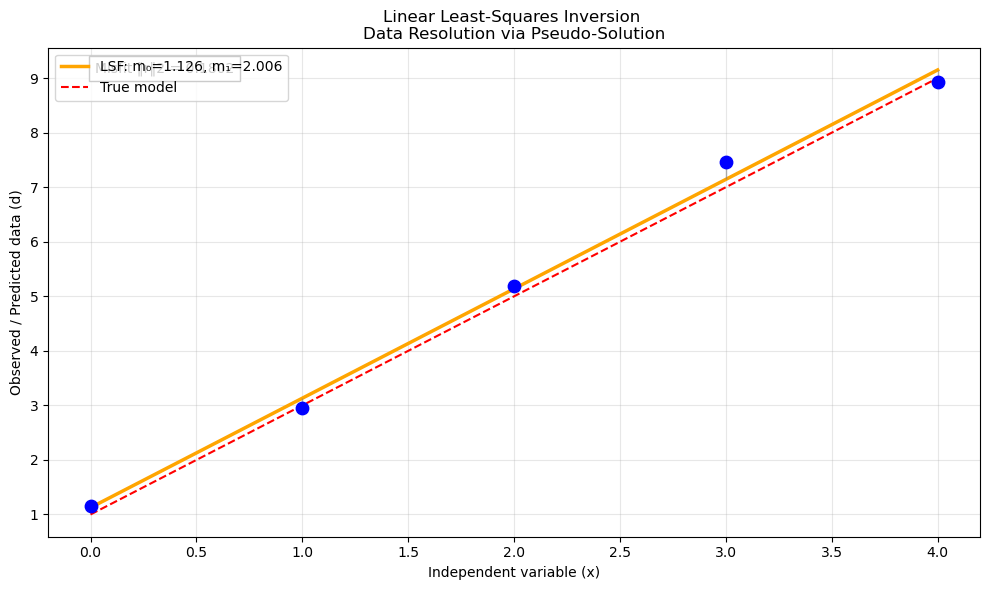

Estimated model m₀ = [1.12572735 2.00598677]
Data resolution matrix diagonal (importances): [0.6 0.3 0.2 0.3 0.6]


In [ ]:
# Here, we demonstrate a simple linear least-squares inversion for an overdetermined system, 
# where we have more data points than model parameters. The code generates synthetic data based on a linear model with added noise, 
# performs the least-squares inversion to estimate the model parameters, and visualizes the results along with the residuals and misfit.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Overdetermined linear system: d = A m  (N=5 > L=2)
# Model: m = [intercept, slope]  :  d_i = m0 + m1 * x_i
# -----------------------------

# Independent variable (e.g., position or time)
x = np.array([0.0, 1.0, 2.0, 3.0, 4.0]) # 5 data points (N=5)

# Forward operator matrix A
A = np.column_stack((np.ones_like(x), x))   # A is a 5x2 matrix where the first column is all ones (for the intercept) and the second column is the x values (for the slope)

# True model (for reference)
m_true = np.array([1.0, 2.0]) # This means the true relationship is d = 1.0 + 2.0 * x (let's say from a known physical process)

# Observed data with noise
np.random.seed(42)
noise = np.random.normal(0, 0.3, len(x)) # Adding Gaussian noise with mean 0 and standard deviation 0.3 to simulate measurement errors or natural variability in the data
d = A @ m_true + noise  # this is the observed data with noise A @ m_true is A times m_true, which gives the true data without noise.
# Adding noise simulates real-world observations that are not perfect.

# Linear least-squares solution (normal equations)
m_est = np.linalg.inv(A.T @ A) @ A.T @ d # This computes the least-squares estimate of the model parameters.


# Predicted data
d_pred = A @ m_est # This is the predicted data based on the estimated model parameters. It represents what the model predicts for the observed data points.

# Residuals
r = d_pred - d #residuals.

plt.figure(figsize=(10, 6))

# Observed and predicted data
plt.scatter(x, d, color='blue', s=80, zorder=3)
plt.plot(x, d_pred, color='orange', linewidth=2.5, label=f'LSF: m₀={m_est[0]:.3f}, m₁={m_est[1]:.3f}')

# True model (for reference)
plt.plot(x, A @ m_true, color='red', linestyle='--', linewidth=1.5, label='True model')

# Residuals as vertical lines
for xi, di, dpi in zip(x, d, d_pred):
    plt.vlines(xi, di, dpi, color='gray', alpha=0.6, linewidth=1)

plt.xlabel('Independent variable (x)')
plt.ylabel('Observed / Predicted data (d)')
plt.title('Linear Least-Squares Inversion \nData Resolution via Pseudo-Solution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show misfit value
misfit = np.sum(r**2)
plt.text(0.05, 0.95, f'Misfit ‖r‖^2 = {misfit:.4f}', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white'))

plt.show()

print(f"Estimated model m0 = {m_est}")
print(f"Data resolution matrix diagonal (importances): {np.diag(A @ np.linalg.pinv(A))}")